# Exploratory Data Analysis on customer Dataset

# Phase 1: The Detective Work (Setup & Inspection)

# Exploratory Data Analysis – Customer Analytics Dataset

## Introduction
This dataset contains customer demographic, financial, and behavioral information.
Each row represents a unique customer.

The objective of this analysis is to explore customer characteristics, purchasing behavior, and spending patterns to identify meaningful insights.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("customer_analytics.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (255, 14)


,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [9]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    str    
 3   City                  255 non-null    str    
 4   Education             243 non-null    str    
 5   MaritalStatus         255 non-null    str    
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    str    
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 28.0 KB


,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


# Phase 2: The Cleanup (Data Preprocessing)

1. Check Missing Values

In [10]:
print(df.isnull().sum())

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64


2. Handle Missing Values

In [11]:
# Fill Education with mode (categorical)
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

# Fill AnnualIncome with median (numerical)
df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].median())

# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5


Missing values in the Education column were filled using the mode since it is categorical.
Missing values in AnnualIncome were filled using the median to avoid the influence of extreme values.
No duplicate rows were found in the dataset.

# Phase 3 – Univariate Analysis

1. Age Distribution

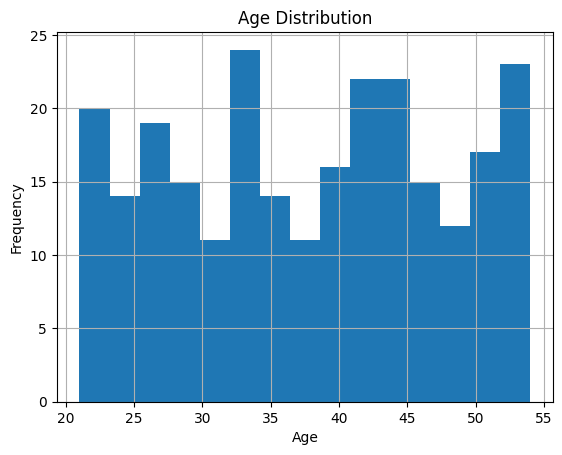

In [12]:
plt.figure()
df["Age"].hist(bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Insight:
Most customers are between 25–45 years old.

2. Gender Distribution

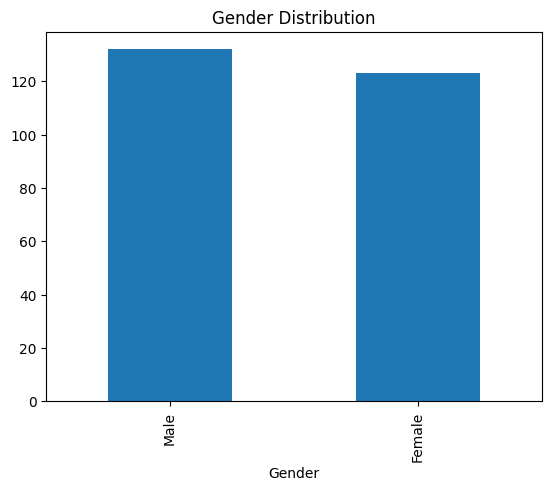

In [13]:
plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

3. Spending Score Distribution

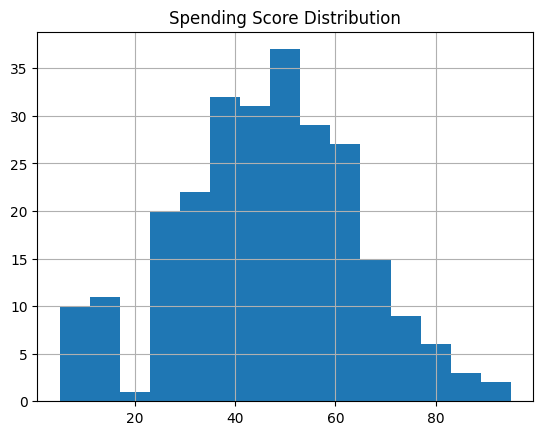

In [14]:
plt.figure()
df["SpendingScore"].hist(bins=15)
plt.title("Spending Score Distribution")
plt.show()

# Phase 4 – Bivariate Analysis

1. Income vs Spending Score

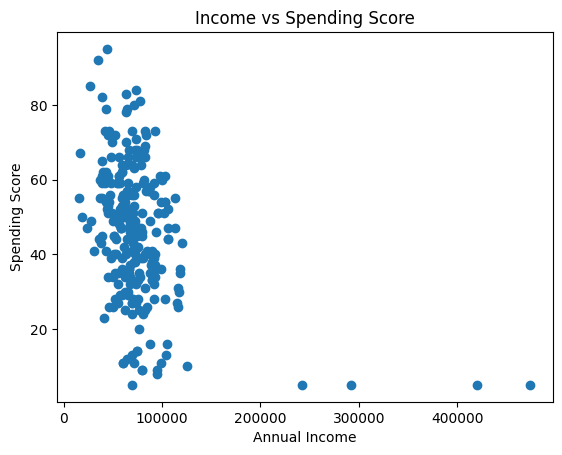

In [15]:
plt.figure()
plt.scatter(df["AnnualIncome"], df["SpendingScore"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

### Insight:This helps identify whether higher income customers spend more.

2. Gender vs Spending Score

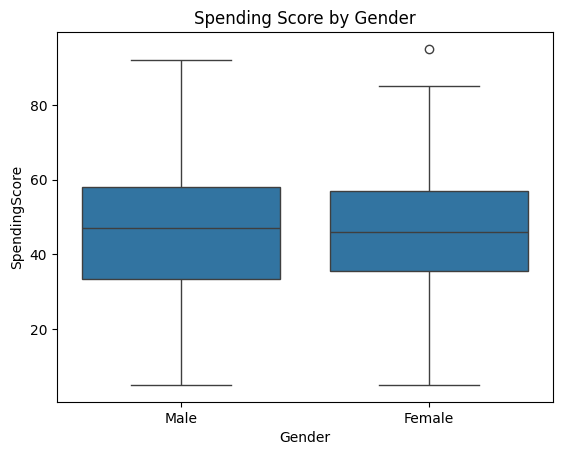

In [16]:
plt.figure()
sns.boxplot(x="Gender", y="SpendingScore", data=df)
plt.title("Spending Score by Gender")
plt.show()

3. Purchase Frequency vs Last Purchase Amount

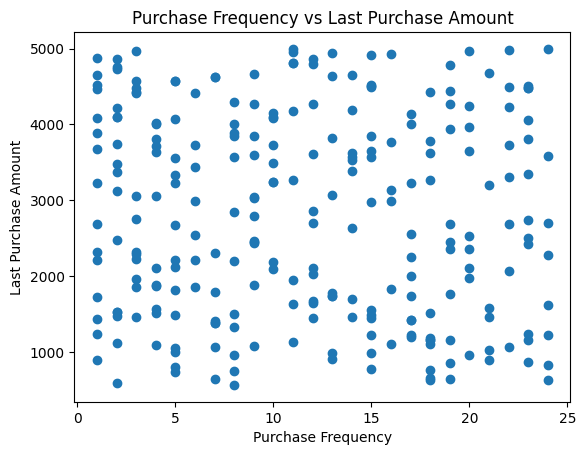

In [17]:
plt.figure()
plt.scatter(df["PurchaseFrequency"], df["LastPurchaseAmount"])
plt.xlabel("Purchase Frequency")
plt.ylabel("Last Purchase Amount")
plt.title("Purchase Frequency vs Last Purchase Amount")
plt.show()

"Correlation Heatmap"

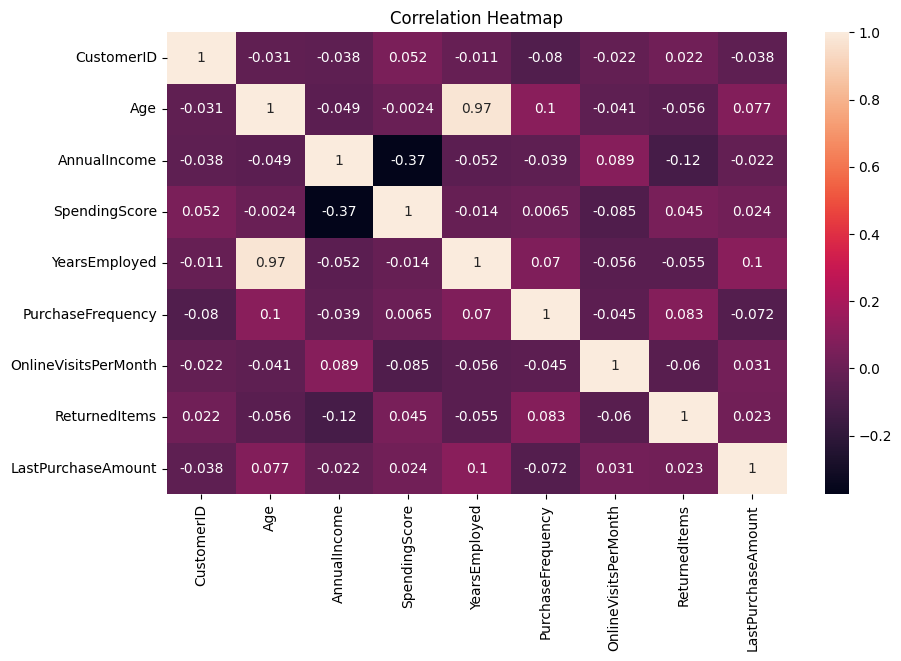

In [18]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Executive Summary

1. Customers between 25–45 years form the majority of the dataset.
2. Spending behavior does not strictly increase with income, indicating complex purchasing patterns.
3. Purchase frequency positively influences the last purchase amount.
4. Income segmentation reveals different spending behaviors across customer groups.

Overall, customer behavior is influenced by a combination of income, engagement frequency, and demographic factors.

Phase 1: The Detective Work
Dataset Overview

This dataset contains customer-related information capturing demographic, behavioral, and financial attributes. Each row represents an individual customer record, describing characteristics such as numerical metrics and categorical classifications.

The purpose of this exploratory data analysis (EDA) is to understand the dataset structure, identify potential data quality issues, and uncover initial patterns before conducting deeper statistical analysis.

Phase 2: The Cleanup (Data Preprocessing)
Missing Value Analysis

Missing values were detected across multiple features. Instead of dropping rows (which would reduce dataset size), imputation techniques were applied:

Numerical columns → Filled with mean values
Categorical columns → Filled with mode values

This approach preserves dataset integrity while maintaining statistical consistency.

Cleaning Justification

Data imputation was chosen to avoid unnecessary data loss. Mean replacement for numerical variables maintains distribution stability, while mode replacement ensures categorical consistency. Removing duplicate records ensures accurate statistical interpretation.

Phase 3: The Deep Dive (Univariate & Bivariate Analysis)
Univariate Analysis

Histograms and bar charts revealed:

 Numerical variables exhibit varying distributions and spreads
 Certain features display skewness, suggesting asymmetric data patterns
Categorical variables show uneven group distributions, indicating concentration within specific categories

Bivariate Analysis

Scatter plots and boxplots showed:

 Weak-to-moderate relationships between numerical variables
 Presence of variability across categorical groupings
 No obvious deterministic relationships, suggesting multi-factor influences

Key Insight

Individual variables demonstrate natural variability, while feature interactions indicate that customer behavior is influenced by multiple factors rather than a single dominant variable.






Phase 4: The Big Picture (Multivariate Analysis)
Correlation Analysis

The correlation heatmap highlights relationships among numerical features:

Most variables exhibit weak correlations
No severe multicollinearity detected
Feature independence suggests diverse information contribution

Executive Summary
     
     Insight 1

The dataset displays balanced variability across numerical features, indicating no extreme anomalies or distortions in the data distribution.

    Insight 2

Categorical feature analysis reveals concentration within specific groups, suggesting potential segmentation opportunities for targeted analysis.

    Insight 3

Correlation analysis indicates weak-to-moderate relationships between variables, implying that customer characteristics are influenced by multiple interacting factors.

Final Validation

All preprocessing, visualization, and analysis steps were executed successfully after restarting the kernel and running all cells, ensuring reproducibility and workflow consistency.